## 1 - Install Packages

In [ ]:
# ============================================================
# Cell 1: Install packages (Colab-safe)
# ============================================================
!pip -q install --upgrade pip
!pip -q install "jax[cpu]" optax pandas matplotlib scikit-learn networkx torch torchvision torchaudio
!pip -q install torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.2 MB/s eta 0:00:00


## 2 - imports and configs

In [ ]:
# ============================================================
# Cell 2: Imports, global config, and output folders
# ============================================================
import os
import json
import time
import math
import random
import copy
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import networkx as nx
import torch
from torch_geometric.datasets import Twitch
from torch_geometric.utils import to_networkx

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())

# -----------------------------
# Global experiment config
# -----------------------------
DATASET_NAMES = ["DE", "EN", "ES", "FR", "PT", "RU"]
SEEDS = [0, 1, 2, 3, 4]   # increase to 10 later if desired

MAIN_METRIC = "f1"
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

DEFAULT_CONFIG = {
    "hidden_dim": 16,          # hidden size per head
    "num_layers": 3,           # number of GAT layers
    "num_heads": 4,            # attention heads in hidden layers
    "dropout_rate": 0.5,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 200,
    "patience": 30,
    "batch_size": None,        # still full-batch over all nodes
    "add_self_loops": True
}

# Ablation grids
ABLATION_GRID = {
    "hidden_dim": [8, 16, 32],
    "num_layers": [2, 3, 4],
    "num_heads": [1, 2, 4, 8],
    "dropout_rate": [0.0, 0.2, 0.5]
}

# -----------------------------
# Paths
# -----------------------------
ROOT_OUTPUT_DIR = "outputs"
METRICS_DIR = os.path.join(ROOT_OUTPUT_DIR, "metrics")
FIGURES_DIR = os.path.join(ROOT_OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(ROOT_OUTPUT_DIR, "models")
SPLITS_DIR = os.path.join(ROOT_OUTPUT_DIR, "splits")

for path in [ROOT_OUTPUT_DIR, METRICS_DIR, FIGURES_DIR, MODELS_DIR, SPLITS_DIR]:
    os.makedirs(path, exist_ok=True)

# -----------------------------
# Numeric settings
# -----------------------------
JAX_DTYPE = jnp.float32
NP_DTYPE = np.float32

print("Output directory:", ROOT_OUTPUT_DIR)
print("Datasets:", DATASET_NAMES)
print("Seeds:", SEEDS)
print("Default config:", DEFAULT_CONFIG)

JAX version: 0.7.2
JAX devices: [CudaDevice(id=0)]
Output directory: outputs
Datasets: ['DE', 'EN', 'ES', 'FR', 'PT', 'RU']
Seeds: [0, 1, 2, 3, 4]
Default config: {'hidden_dim': 16, 'num_layers': 3, 'num_heads': 4, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'max_epochs': 200, 'patience': 30, 'batch_size': None, 'add_self_loops': True}


## 3 - utilities

In [ ]:
# ============================================================
# Cell 3: Utility functions
# ============================================================
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def save_json(obj, path: str) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / exp_vals.sum(axis=1, keepdims=True)

def compute_metrics(y_true: np.ndarray, logits: np.ndarray) -> Dict[str, float]:
    probs = softmax_numpy(logits)
    y_pred = probs.argmax(axis=1)

    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out["f1"] = float(f1_score(y_true, y_pred, average="binary"))
    out["macro_f1"] = float(f1_score(y_true, y_pred, average="macro"))

    # ROC-AUC only if both classes are present
    if len(np.unique(y_true)) == 2:
        try:
            out["roc_auc"] = float(roc_auc_score(y_true, probs[:, 1]))
        except Exception:
            out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = np.nan

    return out

def make_stratified_splits(
    y: np.ndarray,
    seed: int,
    train_ratio: float = 0.60,
    val_ratio: float = 0.20,
    test_ratio: float = 0.20
) -> Dict[str, np.ndarray]:
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8
    n = len(y)
    indices = np.arange(n)

    train_idx, temp_idx, y_train, y_temp = train_test_split(
        indices,
        y,
        test_size=(1.0 - train_ratio),
        random_state=seed,
        stratify=y
    )

    relative_val_ratio = val_ratio / (val_ratio + test_ratio)

    val_idx, test_idx, _, _ = train_test_split(
        temp_idx,
        y_temp,
        test_size=(1.0 - relative_val_ratio),
        random_state=seed,
        stratify=y_temp
    )

    return {
        "train": np.sort(train_idx),
        "val": np.sort(val_idx),
        "test": np.sort(test_idx)
    }

def make_mask(indices: np.ndarray, n: int) -> np.ndarray:
    mask = np.zeros(n, dtype=bool)
    mask[indices] = True
    return mask

def graph_density_undirected(num_nodes: int, num_edges_undirected: int) -> float:
    if num_nodes <= 1:
        return 0.0
    return float((2.0 * num_edges_undirected) / (num_nodes * (num_nodes - 1)))

def degree_stats_from_edge_index(edge_index: np.ndarray, num_nodes: int) -> Dict[str, float]:
    deg = np.zeros(num_nodes, dtype=np.int64)
    src = edge_index[0]
    for u in src:
        deg[u] += 1

    return {
        "avg_degree_directed_count": float(deg.mean()),
        "std_degree_directed_count": float(deg.std()),
        "max_degree_directed_count": int(deg.max())
    }

def add_self_loops_to_edge_index(edge_index: np.ndarray, num_nodes: int) -> np.ndarray:
    self_loops = np.arange(num_nodes, dtype=np.int64)
    self_loops = np.stack([self_loops, self_loops], axis=0)
    edge_index_out = np.concatenate([edge_index, self_loops], axis=1)

    # remove duplicates
    edge_tuples = edge_index_out.T
    edge_tuples = np.unique(edge_tuples, axis=0)
    return edge_tuples.T.astype(np.int64)

def build_incoming_edge_index(edge_index: np.ndarray) -> np.ndarray:
    # GAT aggregation will be over incoming neighbors to each destination node.
    # We keep shape (2, E): row 0 = src, row 1 = dst
    return edge_index.astype(np.int64)

def segment_softmax_numpy_style(scores: jnp.ndarray, dst: jnp.ndarray, num_nodes: int) -> jnp.ndarray:
    # scores: (E,)
    max_per_dst = jax.ops.segment_max(scores, dst, num_segments=num_nodes)
    stabilized = scores - max_per_dst[dst]
    exp_scores = jnp.exp(stabilized)
    denom = jax.ops.segment_sum(exp_scores, dst, num_segments=num_nodes)
    return exp_scores / (denom[dst] + 1e-12)

def plot_training_curves(history: Dict[str, List[float]], title: str, save_path: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

def plot_bar_with_error(
    df: pd.DataFrame,
    metric_col: str,
    std_col: str,
    title: str,
    save_path: str
) -> None:
    plt.figure(figsize=(10, 5))
    x = np.arange(len(df))
    plt.bar(x, df[metric_col].values, yerr=df[std_col].values, capsize=5)
    plt.xticks(x, df["dataset"].values)
    plt.ylabel(metric_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

## 4 - load twitch

In [ ]:
# ============================================================
# Cell 4 (REPLACEMENT v2): Download Twitch MUSAE files directly
# ============================================================
import os
import json
import urllib.request
import urllib.error

RAW_TWITCH_DIR = "data/twitch_manual_direct"
os.makedirs(RAW_TWITCH_DIR, exist_ok=True)

# Notebook names -> raw domain names used by public MUSAE mirrors
DOMAIN_MAP = {
    "DE": "DE",
    "EN": "ENGB",
    "ES": "ES",
    "FR": "FR",
    "PT": "PTBR",
    "RU": "RU",
}

# Public raw file mirror
BASE_RAW_URL = "https://raw.githubusercontent.com/CUAI/Non-Homophily-Large-Scale/master/data/twitch"

def download_if_needed(url: str, path: str) -> None:
    if os.path.exists(path):
        return
    print(f"Downloading {url}")
    try:
        urllib.request.urlretrieve(url, path)
    except Exception as e:
        raise RuntimeError(f"Failed to download {url}\nOriginal error: {repr(e)}")

def graph_density_undirected(num_nodes: int, num_edges_undirected: int) -> float:
    if num_nodes <= 1:
        return 0.0
    return float((2.0 * num_edges_undirected) / (num_nodes * (num_nodes - 1)))

def degree_stats_from_edge_index(edge_index: np.ndarray, num_nodes: int) -> Dict[str, float]:
    deg = np.zeros(num_nodes, dtype=np.int64)
    src = edge_index[0]
    for u in src:
        deg[u] += 1
    return {
        "avg_degree_directed_count": float(deg.mean()),
        "std_degree_directed_count": float(deg.std()),
        "max_degree_directed_count": int(deg.max())
    }

def load_direct_domain(domain_code: str):
    domain_dir = os.path.join(RAW_TWITCH_DIR, domain_code)
    os.makedirs(domain_dir, exist_ok=True)

    edges_path = os.path.join(domain_dir, f"musae_{domain_code}_edges.csv")
    features_path = os.path.join(domain_dir, f"musae_{domain_code}_features.json")
    target_path = os.path.join(domain_dir, f"musae_{domain_code}_target.csv")

    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_edges.csv",
        edges_path
    )
    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_features.json",
        features_path
    )
    download_if_needed(
        f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_target.csv",
        target_path
    )

    edges_df = pd.read_csv(edges_path)
    target_df = pd.read_csv(target_path)

    with open(features_path, "r") as f:
        features_dict = json.load(f)

    required_cols = {"id", "new_id", "mature"}
    missing = required_cols - set(target_df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns {missing} in {target_path}. "
            f"Found columns: {list(target_df.columns)}"
        )

    # Sort by new_id so feature rows line up with JSON keys
    target_df = target_df.sort_values("new_id").reset_index(drop=True)

    original_ids = target_df["id"].astype(int).tolist()
    new_ids = target_df["new_id"].astype(int).tolist()

    original_id_to_row = {oid: i for i, oid in enumerate(original_ids)}
    new_id_to_row = {nid: i for i, nid in enumerate(new_ids)}

    num_nodes = len(target_df)

    # -----------------------------
    # Features keyed by new_id
    # -----------------------------
    feature_keys_int = set(int(k) for k in features_dict.keys())
    if not set(new_ids).issubset(feature_keys_int):
        raise ValueError(
            f"Feature JSON keys do not cover all new_id values for domain {domain_code}."
        )

    max_feat_index = -1
    for nid in new_ids:
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            max_feat_index = max(max_feat_index, max(feat_list))

    num_features = max_feat_index + 1
    x_np = np.zeros((num_nodes, num_features), dtype=np.float32)

    for row_idx, nid in enumerate(new_ids):
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            x_np[row_idx, np.asarray(feat_list, dtype=np.int64)] = 1.0

    # -----------------------------
    # Labels
    # -----------------------------
    y_np = target_df["mature"].astype(int).to_numpy(dtype=np.int64)

    # -----------------------------
    # Edges
    # Try both original-id indexing and new_id indexing.
    # -----------------------------
    edge_cols_lower = {c.lower(): c for c in edges_df.columns}
    if "from" in edge_cols_lower and "to" in edge_cols_lower:
        src_col = edge_cols_lower["from"]
        dst_col = edge_cols_lower["to"]
    else:
        if edges_df.shape[1] < 2:
            raise ValueError(f"Edge file {edges_path} has fewer than 2 columns.")
        src_col = edges_df.columns[0]
        dst_col = edges_df.columns[1]

    src_raw = edges_df[src_col].astype(int).to_numpy()
    dst_raw = edges_df[dst_col].astype(int).to_numpy()

    def build_edges(id_to_row):
        edge_pairs = []
        missing_count = 0
        for s, t in zip(src_raw, dst_raw):
            if s in id_to_row and t in id_to_row:
                edge_pairs.append((id_to_row[s], id_to_row[t]))
            else:
                missing_count += 1
        return edge_pairs, missing_count

    # First try original Twitch ids
    edge_pairs_orig, missing_orig = build_edges(original_id_to_row)

    # Then try new_id indexing
    edge_pairs_new, missing_new = build_edges(new_id_to_row)

    if len(edge_pairs_orig) > 0:
        edge_pairs = edge_pairs_orig
        missing_count = missing_orig
        edge_id_mode = "original_id"
    elif len(edge_pairs_new) > 0:
        edge_pairs = edge_pairs_new
        missing_count = missing_new
        edge_id_mode = "new_id"
    else:
        raise ValueError(
            f"No valid edges remained after trying both original id and new_id alignment "
            f"for domain {domain_code}."
        )

    edge_index_np = np.asarray(edge_pairs, dtype=np.int64).T

    # Remove self-loops if any
    keep = edge_index_np[0] != edge_index_np[1]
    edge_index_np = edge_index_np[:, keep]

    # Undirected summary
    edge_pairs_sorted = np.sort(edge_index_np.T, axis=1)
    unique_undirected_edges = np.unique(edge_pairs_sorted, axis=0)
    num_edges_undirected = int(unique_undirected_edges.shape[0])

    row = {
        "num_nodes": num_nodes,
        "num_edges_directed_count": int(edge_index_np.shape[1]),
        "num_edges_undirected_approx": num_edges_undirected,
        "num_features": int(x_np.shape[1]),
        "class_0_count": int((y_np == 0).sum()),
        "class_1_count": int((y_np == 1).sum()),
        "class_1_fraction": float((y_np == 1).mean()),
        "feature_mean": float(x_np.mean()),
        "feature_std": float(x_np.std()),
        "density_undirected_approx": graph_density_undirected(num_nodes, num_edges_undirected),
        "dropped_edges_due_to_id_mismatch": int(missing_count),
        "edge_id_mode": edge_id_mode,
        **degree_stats_from_edge_index(edge_index_np, num_nodes),
    }

    return x_np, y_np, edge_index_np, row

dataset_objects = {}
dataset_data = {}
dataset_summary_rows = []

for name in DATASET_NAMES:
    raw_code = DOMAIN_MAP[name]
    print(f"Loading Twitch dataset: notebook={name}, raw_domain={raw_code}")

    x_np, y_np, edge_index_np, row = load_direct_domain(raw_code)
    row["dataset"] = name

    edge_index_for_gat = add_self_loops_to_edge_index(edge_index_np, x_np.shape[0])

    dataset_objects[name] = None
    dataset_data[name] = {
        "data_obj": None,
        "x_np": x_np,
        "y_np": y_np,
        "edge_index_np": edge_index_np,
        "edge_index_gat_np": edge_index_for_gat
    }
    dataset_summary_rows.append(row)

dataset_summary_df = pd.DataFrame(dataset_summary_rows).sort_values("dataset").reset_index(drop=True)
display(dataset_summary_df)

dataset_summary_path = os.path.join(METRICS_DIR, "gat_dataset_summary.csv")
dataset_summary_df.to_csv(dataset_summary_path, index=False)

print(f"Saved dataset summary to: {dataset_summary_path}")

Loading Twitch dataset: notebook=DE, raw_domain=DE
Loading Twitch dataset: notebook=EN, raw_domain=ENGB
Loading Twitch dataset: notebook=ES, raw_domain=ES
Loading Twitch dataset: notebook=FR, raw_domain=FR
Loading Twitch dataset: notebook=PT, raw_domain=PTBR
Loading Twitch dataset: notebook=RU, raw_domain=RU


,num_nodes,num_edges_directed_count,num_edges_undirected_approx,num_features,class_0_count,class_1_count,class_1_fraction,feature_mean,feature_std,density_undirected_approx,dropped_edges_due_to_id_mismatch,edge_id_mode,avg_degree_directed_count,std_degree_directed_count,max_degree_directed_count,dataset
0,9498,153138,153138,3170,3756,5742,0.604548,0.006415,0.079833,0.003395,0,new_id,16.123184,43.326980,1260,DE
1,7126,35324,35324,3170,3238,3888,0.545608,0.006538,0.080591,0.001391,0,new_id,4.957059,14.080254,540,EN
2,4648,59382,59382,3170,3288,1360,0.292599,0.006095,0.077829,0.005499,0,new_id,12.775818,28.757542,618,ES
3,6551,112666,112666,3170,4135,2416,0.368799,0.006213,0.078577,0.005251,0,new_id,17.198290,47.013575,1489,FR
4,1912,31299,31299,3169,1251,661,0.345711,0.006275,0.078964,0.017132,0,new_id,16.369770,36.074609,714,PT
5,4385,37304,37304,3170,3310,1075,0.245154,0.006495,0.080330,0.003881,0,new_id,8.507184,26.591757,756,RU


Saved dataset summary to: outputs/metrics/gat_dataset_summary.csv


## 5 - dataset and splits

In [ ]:
# ============================================================
# Cell 5: Train/val/test splits
# ============================================================
all_splits = {}
split_rows = []

for name in DATASET_NAMES:
    y_np = dataset_data[name]["y_np"]
    n = len(y_np)
    all_splits[name] = {}

    for seed in SEEDS:
        splits = make_stratified_splits(
            y=y_np,
            seed=seed,
            train_ratio=TRAIN_RATIO,
            val_ratio=VAL_RATIO,
            test_ratio=TEST_RATIO
        )
        all_splits[name][seed] = splits

        split_rows.append({
            "dataset": name,
            "seed": seed,
            "n_total": n,
            "n_train": len(splits["train"]),
            "n_val": len(splits["val"]),
            "n_test": len(splits["test"]),
            "train_pos_frac": float(y_np[splits["train"]].mean()),
            "val_pos_frac": float(y_np[splits["val"]].mean()),
            "test_pos_frac": float(y_np[splits["test"]].mean())
        })

        save_json(
            {k: v.tolist() for k, v in splits.items()},
            os.path.join(SPLITS_DIR, f"{name}_seed{seed}_splits.json")
        )

splits_df = pd.DataFrame(split_rows).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(splits_df.head(12))

splits_df.to_csv(os.path.join(METRICS_DIR, "gat_split_summary.csv"), index=False)
print("Saved split metadata.")

,dataset,seed,n_total,n_train,n_val,n_test,train_pos_frac,val_pos_frac,test_pos_frac
0,DE,0,9498,5698,1900,1900,0.604598,0.604737,0.604211
1,DE,1,9498,5698,1900,1900,0.604598,0.604211,0.604737
2,DE,2,9498,5698,1900,1900,0.604598,0.604737,0.604211
3,DE,3,9498,5698,1900,1900,0.604598,0.604737,0.604211
4,DE,4,9498,5698,1900,1900,0.604598,0.604737,0.604211
5,EN,0,7126,4275,1425,1426,0.545497,0.545965,0.545582
6,EN,1,7126,4275,1425,1426,0.545497,0.545965,0.545582
7,EN,2,7126,4275,1425,1426,0.545497,0.545965,0.545582
8,EN,3,7126,4275,1425,1426,0.545497,0.545965,0.545582
9,EN,4,7126,4275,1425,1426,0.545497,0.545965,0.545582


Saved split metadata.


## 6 - GAT model

In [ ]:
# ============================================================
# Cell 6: GAT model definition (class-based, JAX ops)
# ============================================================
class GAT:
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int = 2,
        num_heads: int = 4,
        dropout_rate: float = 0.5
    ):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate

    def init_params(self, rng_key: jax.Array) -> Dict:
        params = {"layers": []}

        dims = [self.input_dim]
        for _ in range(self.num_layers - 1):
            dims.append(self.hidden_dim * self.num_heads)
        dims.append(self.output_dim)

        n_param_groups = self.num_layers
        keys = jax.random.split(rng_key, 4 * n_param_groups)

        key_ptr = 0
        for layer_idx in range(self.num_layers):
            in_dim = dims[layer_idx]

            if layer_idx < self.num_layers - 1:
                heads = self.num_heads
                out_dim_per_head = self.hidden_dim
            else:
                heads = 1
                out_dim_per_head = self.output_dim

            w_key = keys[key_ptr]
            a_src_key = keys[key_ptr + 1]
            a_dst_key = keys[key_ptr + 2]
            key_ptr += 4

            limit = math.sqrt(6.0 / (in_dim + heads * out_dim_per_head))
            W = jax.random.uniform(
                w_key,
                shape=(in_dim, heads, out_dim_per_head),
                minval=-limit,
                maxval=limit,
                dtype=JAX_DTYPE
            )

            a_src = jax.random.uniform(
                a_src_key,
                shape=(heads, out_dim_per_head),
                minval=-limit,
                maxval=limit,
                dtype=JAX_DTYPE
            )
            a_dst = jax.random.uniform(
                a_dst_key,
                shape=(heads, out_dim_per_head),
                minval=-limit,
                maxval=limit,
                dtype=JAX_DTYPE
            )

            b = jnp.zeros((heads, out_dim_per_head), dtype=JAX_DTYPE)

            params["layers"].append({
                "W": W,
                "a_src": a_src,
                "a_dst": a_dst,
                "b": b
            })

        return params

    def _dropout(self, x: jnp.ndarray, rng_key: Optional[jax.Array], train: bool) -> jnp.ndarray:
        if (not train) or (self.dropout_rate <= 0.0) or (rng_key is None):
            return x
        keep_prob = 1.0 - self.dropout_rate
        mask = jax.random.bernoulli(rng_key, p=keep_prob, shape=x.shape)
        return jnp.where(mask, x / keep_prob, 0.0)

    def _gat_layer(
        self,
        layer_params: Dict,
        x: jnp.ndarray,
        edge_index: jnp.ndarray,
        num_nodes: int,
        rng_key: Optional[jax.Array],
        train: bool,
        concat: bool
    ) -> jnp.ndarray:
        # x: (N, Fin)
        # W: (Fin, H, Fout)
        W = layer_params["W"]
        a_src = layer_params["a_src"]
        a_dst = layer_params["a_dst"]
        b = layer_params["b"]

        src = edge_index[0]
        dst = edge_index[1]

        # linear projection
        h = jnp.einsum("nf,fho->nho", x, W) + b[None, :, :]   # (N, H, Fout)

        # source / target node projected embeddings on edges
        h_src = h[src]    # (E, H, Fout)
        h_dst = h[dst]    # (E, H, Fout)

        # additive attention score
        e_src = jnp.sum(h_src * a_src[None, :, :], axis=-1)   # (E, H)
        e_dst = jnp.sum(h_dst * a_dst[None, :, :], axis=-1)   # (E, H)
        e = jax.nn.leaky_relu(e_src + e_dst, negative_slope=0.2)  # (E, H)

        # edge dropout on attention logits if training
        if train and rng_key is not None and self.dropout_rate > 0.0:
            e = self._dropout(e, rng_key, train=True)

        # softmax over incoming edges per destination node, separately for each head
        def normalize_one_head(e_head):
            return segment_softmax_numpy_style(e_head, dst, num_nodes)

        alpha = jax.vmap(normalize_one_head, in_axes=1, out_axes=1)(e)   # (E, H)

        # weighted sum of source messages into dst
        messages = h_src * alpha[:, :, None]   # (E, H, Fout)

        def aggregate_one_head(msg_head):
            return jax.ops.segment_sum(msg_head, dst, num_segments=num_nodes)

        out = jax.vmap(aggregate_one_head, in_axes=1, out_axes=1)(messages)  # (N, H, Fout)

        if concat:
            out = out.reshape(num_nodes, -1)   # (N, H*Fout)
        else:
            out = out.mean(axis=1)             # (N, Fout)

        return out

    def __call__(
        self,
        params: Dict,
        x: jnp.ndarray,
        edge_index: jnp.ndarray,
        rng_key: Optional[jax.Array] = None,
        train: bool = False
    ) -> jnp.ndarray:
        h = x
        n_layers = len(params["layers"])

        layer_keys = None
        if rng_key is not None:
            layer_keys = jax.random.split(rng_key, n_layers)

        for i, layer in enumerate(params["layers"]):
            is_last = (i == n_layers - 1)
            h = self._gat_layer(
                layer_params=layer,
                x=h,
                edge_index=edge_index,
                num_nodes=h.shape[0],
                rng_key=None if layer_keys is None else layer_keys[i],
                train=train,
                concat=(not is_last)
            )

            if not is_last:
                h = jax.nn.elu(h)

        return h

print("GAT class defined.")

GAT class defined.


## 7 - training and eval functions

In [ ]:
# ============================================================
# Cell 7: Training and evaluation functions
# ============================================================
@dataclass
class TrainState:
    params: Dict
    opt_state: optax.OptState
    best_params: Dict
    best_val_metric: float
    best_epoch: int
    history: Dict[str, List[float]]

def cross_entropy_loss(logits: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
    y_onehot = jax.nn.one_hot(y, num_classes=logits.shape[1])
    log_probs = jax.nn.log_softmax(logits, axis=1)
    return -jnp.mean(jnp.sum(y_onehot * log_probs, axis=1))

def l2_weight_penalty(params: Dict) -> jnp.ndarray:
    penalty = 0.0
    for layer in params["layers"]:
        penalty = penalty + jnp.sum(layer["W"] ** 2)
        penalty = penalty + jnp.sum(layer["a_src"] ** 2)
        penalty = penalty + jnp.sum(layer["a_dst"] ** 2)
    return penalty

def build_optimizer(learning_rate: float, weight_decay: float):
    # Decoupled weight decay
    return optax.adamw(learning_rate=learning_rate, weight_decay=weight_decay)

def evaluate_split(
    model: GAT,
    params: Dict,
    x_jnp: jnp.ndarray,
    edge_index_jnp: jnp.ndarray,
    y_np: np.ndarray,
    split_idx: np.ndarray
) -> Tuple[float, Dict[str, float], np.ndarray]:
    logits = model(params, x_jnp, edge_index_jnp, rng_key=None, train=False)
    logits_np = np.asarray(logits)
    split_logits = logits_np[split_idx]
    split_y = y_np[split_idx]

    loss_val = float(cross_entropy_loss(jnp.asarray(split_logits), jnp.asarray(split_y)))
    metrics = compute_metrics(split_y, split_logits)
    return loss_val, metrics, split_logits

def train_one_run(
    x_np: np.ndarray,
    y_np: np.ndarray,
    edge_index_np: np.ndarray,
    splits: Dict[str, np.ndarray],
    seed: int,
    config: Dict,
    dataset_name: str,
    run_name: str,
    save_training_curve: bool = True
) -> Dict:
    set_global_seed(seed)

    x_jnp = jnp.asarray(x_np, dtype=JAX_DTYPE)
    y_jnp = jnp.asarray(y_np, dtype=jnp.int32)
    edge_index_jnp = jnp.asarray(edge_index_np, dtype=jnp.int32)

    train_idx = splits["train"]
    val_idx = splits["val"]
    test_idx = splits["test"]

    input_dim = x_np.shape[1]
    output_dim = len(np.unique(y_np))

    model = GAT(
        input_dim=input_dim,
        hidden_dim=config["hidden_dim"],
        output_dim=output_dim,
        num_layers=config["num_layers"],
        num_heads=config["num_heads"],
        dropout_rate=config["dropout_rate"]
    )

    init_key = jax.random.PRNGKey(seed)
    params = model.init_params(init_key)

    optimizer = build_optimizer(
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    opt_state = optimizer.init(params)

    @jax.jit
    def train_step(params, opt_state, step_key):
        def loss_fn(p):
            logits = model(p, x_jnp, edge_index_jnp, rng_key=step_key, train=True)
            train_logits = logits[train_idx]
            train_y = y_jnp[train_idx]
            data_loss = cross_entropy_loss(train_logits, train_y)
            return data_loss

        loss_value, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss_value

    state = TrainState(
        params=params,
        opt_state=opt_state,
        best_params=copy.deepcopy(params),
        best_val_metric=-np.inf,
        best_epoch=-1,
        history={
            "train_loss": [],
            "val_loss": [],
            "train_f1": [],
            "val_f1": []
        }
    )

    patience_counter = 0
    t0 = time.time()

    for epoch in range(config["max_epochs"]):
        step_key = jax.random.PRNGKey(seed * 10000 + epoch)
        state.params, state.opt_state, train_loss_jnp = train_step(state.params, state.opt_state, step_key)

        train_loss, train_metrics, _ = evaluate_split(model, state.params, x_jnp, edge_index_jnp, y_np, train_idx)
        val_loss, val_metrics, _ = evaluate_split(model, state.params, x_jnp, edge_index_jnp, y_np, val_idx)

        state.history["train_loss"].append(train_loss)
        state.history["val_loss"].append(val_loss)
        state.history["train_f1"].append(train_metrics["f1"])
        state.history["val_f1"].append(val_metrics["f1"])

        current_val_metric = val_metrics[MAIN_METRIC]

        if current_val_metric > state.best_val_metric:
            state.best_val_metric = current_val_metric
            state.best_epoch = epoch
            state.best_params = copy.deepcopy(state.params)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            break

    elapsed = time.time() - t0

    # Final evaluation with best params
    best_params = state.best_params

    train_loss, train_metrics, train_logits = evaluate_split(model, best_params, x_jnp, edge_index_jnp, y_np, train_idx)
    val_loss, val_metrics, val_logits = evaluate_split(model, best_params, x_jnp, edge_index_jnp, y_np, val_idx)
    test_loss, test_metrics, test_logits = evaluate_split(model, best_params, x_jnp, edge_index_jnp, y_np, test_idx)

    result = {
        "dataset": dataset_name,
        "seed": seed,
        "run_name": run_name,
        "hidden_dim": config["hidden_dim"],
        "num_layers": config["num_layers"],
        "num_heads": config["num_heads"],
        "dropout_rate": config["dropout_rate"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "max_epochs": config["max_epochs"],
        "patience": config["patience"],
        "best_epoch": state.best_epoch,
        "elapsed_seconds": elapsed,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "train_roc_auc": train_metrics["roc_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "history": state.history,
        "best_params": best_params
    }

    if save_training_curve:
        curve_path = os.path.join(
            FIGURES_DIR,
            f"{dataset_name}_{run_name}_seed{seed}_training_curve.png"
        )
        plot_training_curves(
            state.history,
            title=f"{dataset_name} | {run_name} | seed={seed}",
            save_path=curve_path
        )

    return result

print("Training utilities ready.")

Training utilities ready.


## 8 - main GAT baselin run

Running default GAT on dataset: DE
  Seed 0 ...


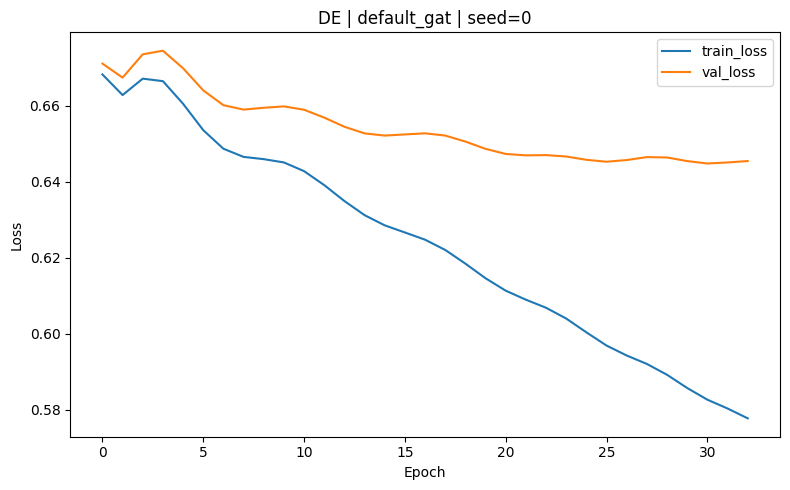

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GAT on dataset: EN
  Seed 0 ...


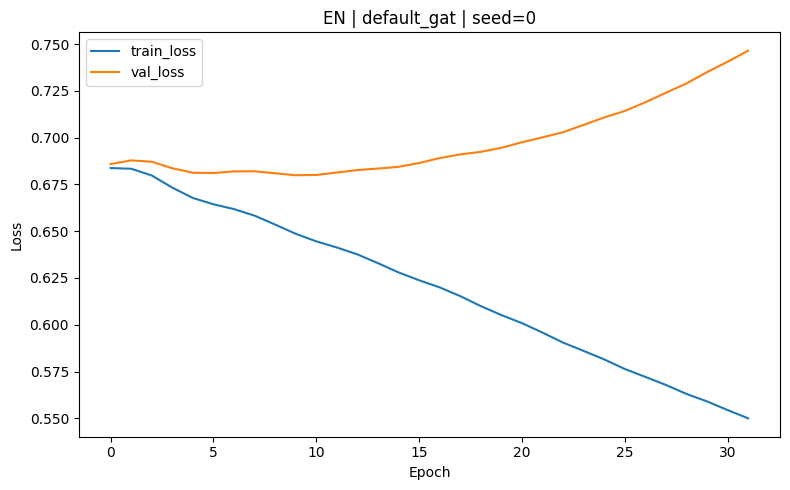

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GAT on dataset: ES
  Seed 0 ...


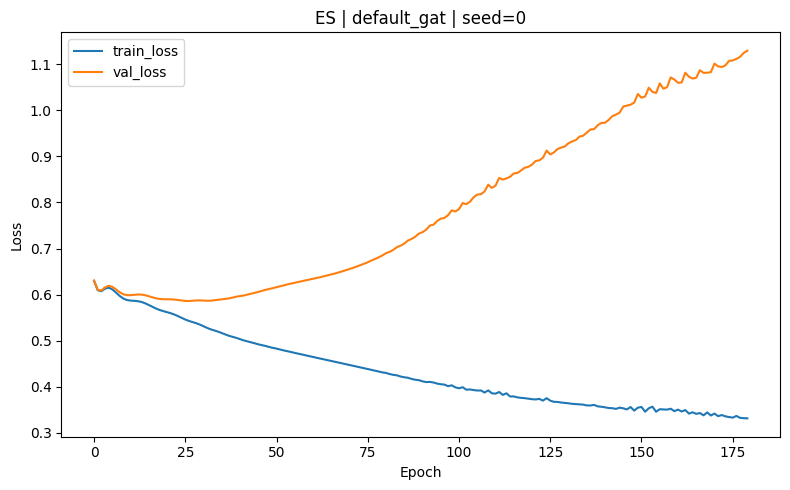

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GAT on dataset: FR
  Seed 0 ...


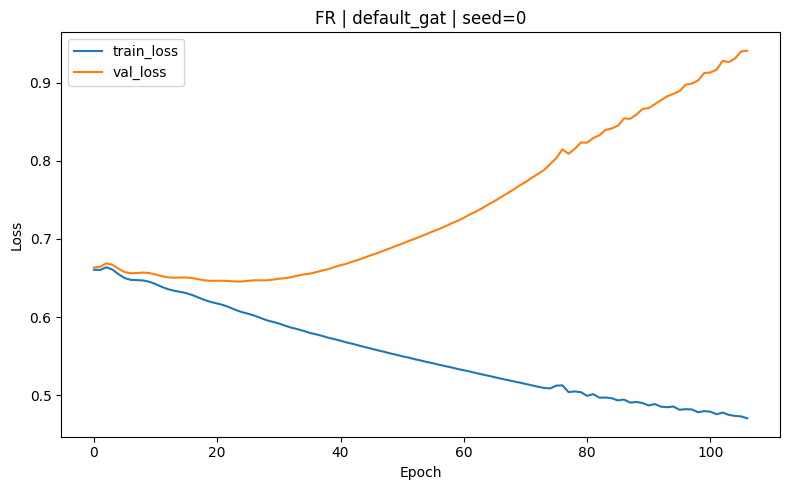

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GAT on dataset: PT
  Seed 0 ...


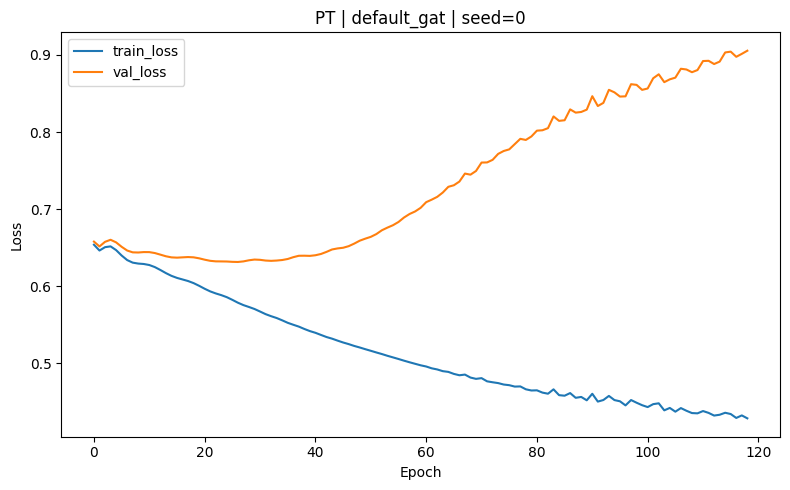

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GAT on dataset: RU
  Seed 0 ...


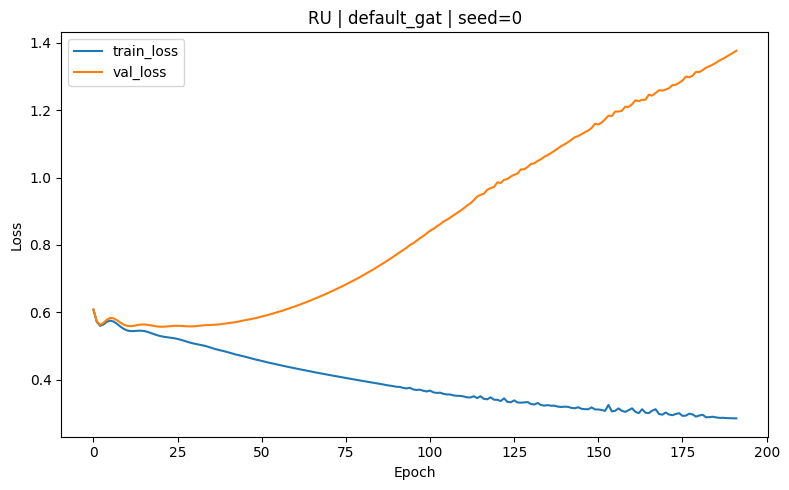

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...


,dataset,seed,run_name,hidden_dim,num_layers,num_heads,dropout_rate,learning_rate,weight_decay,max_epochs,...,test_accuracy,train_f1,val_f1,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc
0,DE,0,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.608421,0.756049,0.753785,0.754293,0.396688,0.386079,0.395281,0.632702,0.610914,0.620557
1,DE,1,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.602105,0.757174,0.754954,0.750988,0.407697,0.396907,0.380730,0.643210,0.623888,0.637481
2,DE,2,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.606316,0.755048,0.754034,0.754109,0.388908,0.387502,0.383651,0.642760,0.620345,0.622303
3,DE,3,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.612632,0.763333,0.754487,0.752355,0.466352,0.449262,0.431733,0.698303,0.655160,0.694464
4,DE,4,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.652632,0.789175,0.769468,0.745370,0.669615,0.636807,0.599506,0.766001,0.696035,0.670990
5,EN,0,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.554698,0.710054,0.705882,0.707508,0.390899,0.378164,0.387528,0.605079,0.580395,0.576363
6,EN,1,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.546283,0.706280,0.700508,0.703347,0.383577,0.375144,0.369557,0.570107,0.524747,0.552339
7,EN,2,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.540673,0.707716,0.701192,0.700777,0.376801,0.362572,0.356421,0.618881,0.552409,0.615521
8,EN,3,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.548387,0.709628,0.702479,0.703499,0.384561,0.369097,0.378220,0.622835,0.552020,0.579941
9,EN,4,default_gat,16,3,4,0.5,0.001,0.0001,200,...,0.545582,0.708137,0.705292,0.704918,0.368246,0.361765,0.358557,0.576145,0.577928,0.549000


Saved per-run results to: outputs/metrics/gat_results.csv


In [ ]:
# ============================================================
# Cell 8: Main experiment loop (default GAT baseline)
# ============================================================
default_results = []
representative_result = None

for dataset_name in DATASET_NAMES:
    x_np = dataset_data[dataset_name]["x_np"]
    y_np = dataset_data[dataset_name]["y_np"]
    edge_index_np = dataset_data[dataset_name]["edge_index_gat_np"]

    print("=" * 80)
    print(f"Running default GAT on dataset: {dataset_name}")

    for seed in SEEDS:
        print(f"  Seed {seed} ...")
        result = train_one_run(
            x_np=x_np,
            y_np=y_np,
            edge_index_np=edge_index_np,
            splits=all_splits[dataset_name][seed],
            seed=seed,
            config=DEFAULT_CONFIG,
            dataset_name=dataset_name,
            run_name="default_gat",
            save_training_curve=(seed == SEEDS[0])  # only save first seed per dataset
        )

        row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
        default_results.append(row)

        if representative_result is None:
            representative_result = result

default_results_df = pd.DataFrame(default_results).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(default_results_df.head(12))

default_results_path = os.path.join(METRICS_DIR, "gat_results.csv")
default_results_df.to_csv(default_results_path, index=False)

print(f"Saved per-run results to: {default_results_path}")

## 9 - aggregate results

In [ ]:
# ============================================================
# Cell 9: Aggregate default results
# ============================================================
agg_df = (
    default_results_df
    .groupby("dataset", as_index=False)
    .agg({
        "test_accuracy": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "test_macro_f1": ["mean", "std"],
        "test_roc_auc": ["mean", "std"],
        "val_f1": ["mean", "std"],
        "elapsed_seconds": ["mean"]
    })
)

agg_df.columns = [
    "dataset",
    "test_accuracy_mean", "test_accuracy_std",
    "test_f1_mean", "test_f1_std",
    "test_macro_f1_mean", "test_macro_f1_std",
    "test_roc_auc_mean", "test_roc_auc_std",
    "val_f1_mean", "val_f1_std",
    "elapsed_seconds_mean"
]

display(agg_df)

agg_path = os.path.join(METRICS_DIR, "gat_results_aggregated.csv")
agg_df.to_csv(agg_path, index=False)

print(f"Saved aggregated results to: {agg_path}")

,dataset,test_accuracy_mean,test_accuracy_std,test_f1_mean,test_f1_std,test_macro_f1_mean,test_macro_f1_std,test_roc_auc_mean,test_roc_auc_std,val_f1_mean,val_f1_std,elapsed_seconds_mean
0,DE,0.616421,0.020595,0.751423,0.003645,0.438180,0.092442,0.649159,0.032422,0.757346,0.006791,21.194050
1,EN,0.547125,0.005091,0.704010,0.002461,0.370057,0.013137,0.574633,0.026726,0.703071,0.002413,14.686668
2,ES,0.680860,0.010763,0.371929,0.162699,0.576828,0.073127,0.644976,0.041610,0.357684,0.156186,39.350471
3,FR,0.614188,0.011944,0.475988,0.014427,0.585278,0.011177,0.617041,0.014504,0.487992,0.022095,39.442139
4,PT,0.648042,0.011735,0.399489,0.164395,0.572051,0.072359,0.605053,0.085302,0.409149,0.157986,30.796650
5,RU,0.707412,0.045350,0.123109,0.107226,0.472418,0.036591,0.499929,0.038697,0.136062,0.131094,29.988843


Saved aggregated results to: outputs/metrics/gat_results_aggregated.csv


## 10 - plot default GAT results

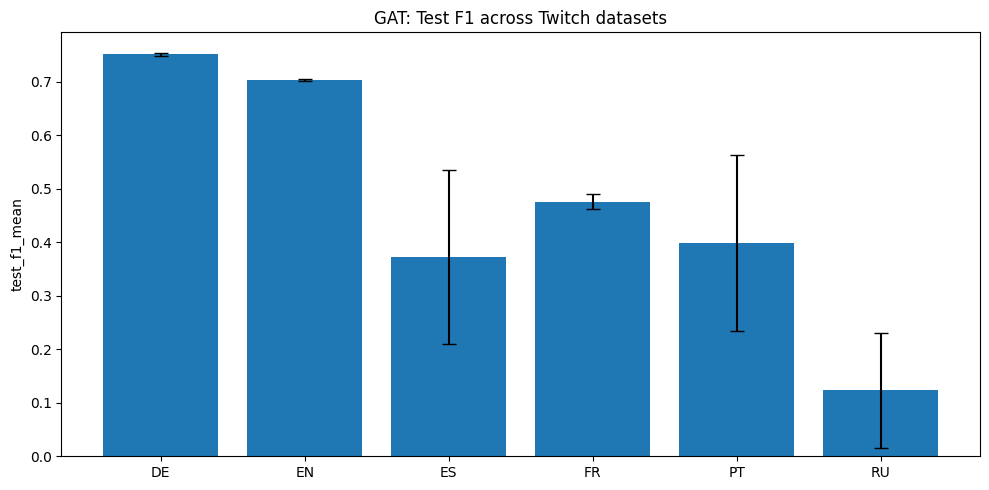

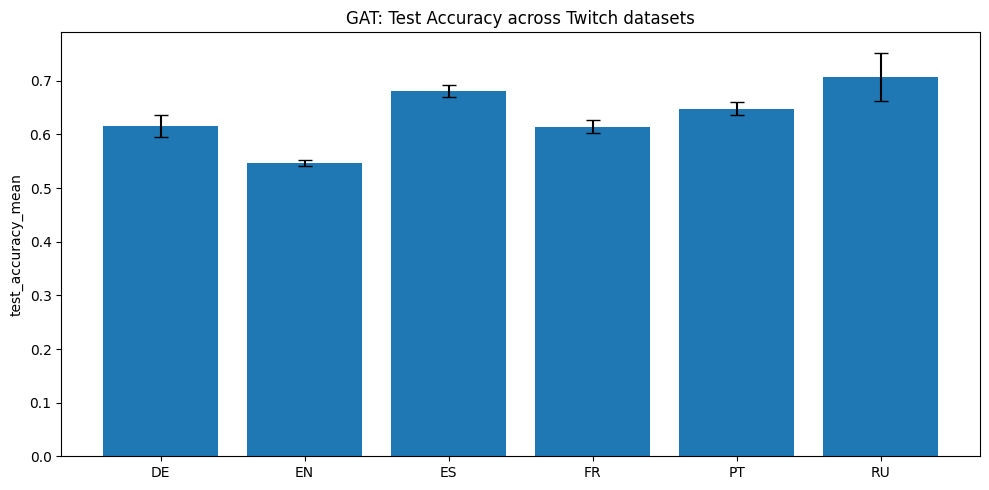

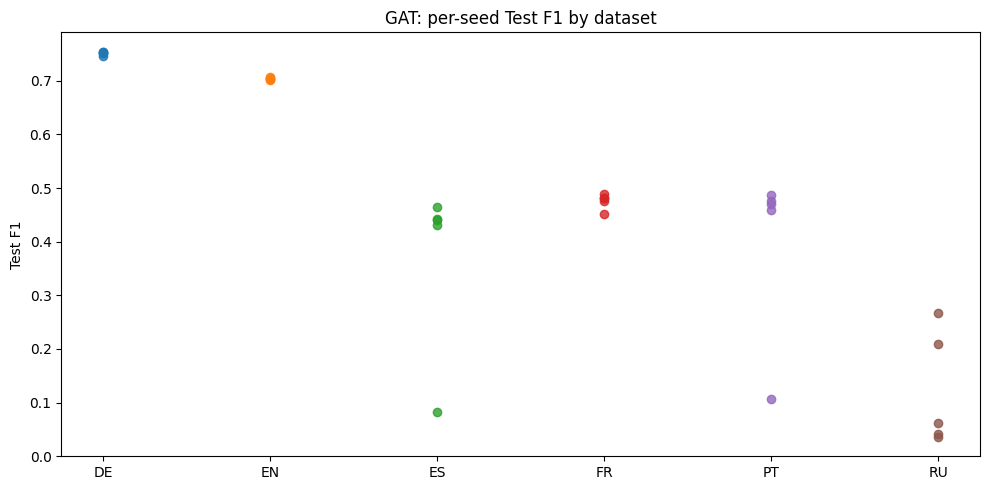

Saved default result plots.


In [ ]:
# ============================================================
# Cell 10: Plots for default GAT results
# ============================================================
# Plot 1: Test F1 mean +/- std across datasets
plot_bar_with_error(
    df=agg_df,
    metric_col="test_f1_mean",
    std_col="test_f1_std",
    title="GAT: Test F1 across Twitch datasets",
    save_path=os.path.join(FIGURES_DIR, "gat_test_f1_barplot.png")
)

# Plot 2: Test accuracy mean +/- std across datasets
plot_bar_with_error(
    df=agg_df,
    metric_col="test_accuracy_mean",
    std_col="test_accuracy_std",
    title="GAT: Test Accuracy across Twitch datasets",
    save_path=os.path.join(FIGURES_DIR, "gat_test_accuracy_barplot.png")
)

# Plot 3: Per-seed F1 scatter by dataset
plt.figure(figsize=(10, 5))
for i, dataset_name in enumerate(DATASET_NAMES):
    vals = default_results_df.loc[default_results_df["dataset"] == dataset_name, "test_f1"].values
    x = np.full_like(vals, fill_value=i, dtype=float)
    plt.scatter(x, vals, alpha=0.8)

plt.xticks(np.arange(len(DATASET_NAMES)), DATASET_NAMES)
plt.ylabel("Test F1")
plt.title("GAT: per-seed Test F1 by dataset")
plt.tight_layout()
scatter_path = os.path.join(FIGURES_DIR, "gat_test_f1_scatter.png")
plt.savefig(scatter_path, dpi=200)
plt.show()

print("Saved default result plots.")

## 11 - run ablations

In [11]:
# ============================================================
# Cell 11: GAT ablations
# ============================================================
# To keep runtime manageable, do ablations on a subset of seeds by default.
ABLATION_SEEDS = [0, 1, 2]

ablation_results = []

# -----------------------------
# Ablation A: hidden dimension
# -----------------------------
for hidden_dim in ABLATION_GRID["hidden_dim"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["hidden_dim"] = hidden_dim

    for dataset_name in DATASET_NAMES:
        x_np = dataset_data[dataset_name]["x_np"]
        y_np = dataset_data[dataset_name]["y_np"]
        edge_index_np = dataset_data[dataset_name]["edge_index_gat_np"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation hidden_dim={hidden_dim}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                x_np=x_np,
                y_np=y_np,
                edge_index_np=edge_index_np,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_hidden{hidden_dim}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
            row["ablation_type"] = "hidden_dim"
            row["ablation_value"] = hidden_dim
            ablation_results.append(row)

# -----------------------------
# Ablation B: number of layers
# -----------------------------
for num_layers in ABLATION_GRID["num_layers"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["num_layers"] = num_layers

    for dataset_name in DATASET_NAMES:
        x_np = dataset_data[dataset_name]["x_np"]
        y_np = dataset_data[dataset_name]["y_np"]
        edge_index_np = dataset_data[dataset_name]["edge_index_gat_np"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation num_layers={num_layers}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                x_np=x_np,
                y_np=y_np,
                edge_index_np=edge_index_np,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_layers{num_layers}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
            row["ablation_type"] = "num_layers"
            row["ablation_value"] = num_layers
            ablation_results.append(row)

# -----------------------------
# Ablation C: number of heads
# -----------------------------
for num_heads in ABLATION_GRID["num_heads"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["num_heads"] = num_heads

    for dataset_name in DATASET_NAMES:
        x_np = dataset_data[dataset_name]["x_np"]
        y_np = dataset_data[dataset_name]["y_np"]
        edge_index_np = dataset_data[dataset_name]["edge_index_gat_np"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation num_heads={num_heads}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                x_np=x_np,
                y_np=y_np,
                edge_index_np=edge_index_np,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_heads{num_heads}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
            row["ablation_type"] = "num_heads"
            row["ablation_value"] = num_heads
            ablation_results.append(row)

# -----------------------------
# Ablation C: dropout rate
# -----------------------------
for dropout_rate in ABLATION_GRID["dropout_rate"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["dropout_rate"] = dropout_rate

    for dataset_name in DATASET_NAMES:
        x_np = dataset_data[dataset_name]["x_np"]
        y_np = dataset_data[dataset_name]["y_np"]
        edge_index_np = dataset_data[dataset_name]["edge_index_gat_np"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation dropout={dropout_rate}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                x_np=x_np,
                y_np=y_np,
                edge_index_np=edge_index_np,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_dropout{dropout_rate}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k not in ["history", "best_params"]}
            row["ablation_type"] = "dropout_rate"
            row["ablation_value"] = dropout_rate
            ablation_results.append(row)

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    ["ablation_type", "ablation_value", "dataset", "seed"]
).reset_index(drop=True)

display(ablation_results_df.head(20))

ablation_results_path = os.path.join(METRICS_DIR, "gat_ablation_results.csv")
ablation_results_df.to_csv(ablation_results_path, index=False)
print(f"Saved ablation results to: {ablation_results_path}")

[Ablation hidden_dim=8] dataset=DE, seed=0
[Ablation hidden_dim=8] dataset=DE, seed=1
[Ablation hidden_dim=8] dataset=DE, seed=2
[Ablation hidden_dim=8] dataset=EN, seed=0
[Ablation hidden_dim=8] dataset=EN, seed=1
[Ablation hidden_dim=8] dataset=EN, seed=2
[Ablation hidden_dim=8] dataset=ES, seed=0
[Ablation hidden_dim=8] dataset=ES, seed=1
[Ablation hidden_dim=8] dataset=ES, seed=2
[Ablation hidden_dim=8] dataset=FR, seed=0
[Ablation hidden_dim=8] dataset=FR, seed=1
[Ablation hidden_dim=8] dataset=FR, seed=2
[Ablation hidden_dim=8] dataset=PT, seed=0
[Ablation hidden_dim=8] dataset=PT, seed=1
[Ablation hidden_dim=8] dataset=PT, seed=2
[Ablation hidden_dim=8] dataset=RU, seed=0
[Ablation hidden_dim=8] dataset=RU, seed=1
[Ablation hidden_dim=8] dataset=RU, seed=2
[Ablation hidden_dim=16] dataset=DE, seed=0
[Ablation hidden_dim=16] dataset=DE, seed=1
[Ablation hidden_dim=16] dataset=DE, seed=2
[Ablation hidden_dim=16] dataset=EN, seed=0
[Ablation hidden_dim=16] dataset=EN, seed=1
[Ablat

,dataset,seed,run_name,hidden_dim,num_layers,num_heads,dropout_rate,learning_rate,weight_decay,max_epochs,...,val_f1,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc,ablation_type,ablation_value
0,DE,0,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.753785,0.754293,0.396688,0.386079,0.395281,0.632713,0.610915,0.620585,dropout_rate,0.0
1,DE,1,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.754954,0.750988,0.407697,0.396907,0.380730,0.643176,0.623850,0.637454,dropout_rate,0.0
2,DE,2,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.754034,0.754109,0.388908,0.387502,0.383651,0.642781,0.620347,0.622325,dropout_rate,0.0
3,EN,0,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.705882,0.707508,0.390899,0.378164,0.387528,0.605082,0.580450,0.576296,dropout_rate,0.0
4,EN,1,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.700508,0.703347,0.383577,0.375144,0.369557,0.570111,0.524768,0.552377,dropout_rate,0.0
5,EN,2,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.701192,0.700777,0.376801,0.362572,0.356421,0.618867,0.552371,0.615594,dropout_rate,0.0
6,ES,0,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.448911,0.452145,0.830531,0.594210,0.593696,0.926873,0.610087,0.634714,dropout_rate,0.0
7,ES,1,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.081505,0.081761,0.453539,0.445684,0.446198,0.544179,0.505442,0.572987,dropout_rate,0.0
8,ES,2,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.437607,0.408859,0.848529,0.589784,0.568137,0.938005,0.626978,0.614887,dropout_rate,0.0
9,FR,0,ablation_dropout0.0,16,3,4,0.0,0.001,0.0001,200,...,0.492582,0.507782,0.745940,0.586875,0.595171,0.843108,0.606836,0.618438,dropout_rate,0.0


Saved ablation results to: outputs/metrics/gat_ablation_results.csv


In [ ]:
print("Completed ablation runs so far:", len(ablation_results))

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    ["ablation_type", "ablation_value", "dataset", "seed"]
).reset_index(drop=True)

display(ablation_results_df.tail(30))

partial_path = os.path.join(METRICS_DIR, "gat_ablation_results_partial.csv")
ablation_results_df.to_csv(partial_path, index=False)

print(f"Saved partial ablation results to: {partial_path}")

Completed ablation runs so far: 106


,dataset,seed,run_name,hidden_dim,num_layers,num_heads,dropout_rate,learning_rate,weight_decay,max_epochs,...,val_f1,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc,ablation_type,ablation_value
76,EN,1,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.700508,0.703347,0.383577,0.375144,0.369557,0.570107,0.524747,0.552339,num_layers,3
77,EN,2,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.701192,0.700777,0.376801,0.362572,0.356421,0.618881,0.552409,0.615521,num_layers,3
78,ES,0,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.431858,0.464957,0.799215,0.591991,0.609734,0.906016,0.624718,0.645684,num_layers,3
79,ES,1,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.081505,0.081761,0.453539,0.445684,0.446198,0.544177,0.505431,0.572982,num_layers,3
80,ES,2,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.458955,0.430476,0.775342,0.619961,0.603253,0.882321,0.654345,0.664570,num_layers,3
81,FR,0,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.486993,0.485159,0.707944,0.594913,0.589692,0.804009,0.621771,0.629206,num_layers,3
82,FR,1,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.493802,0.451613,0.732940,0.598596,0.567167,0.832303,0.625234,0.593214,num_layers,3
83,FR,2,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.453061,0.479438,0.760686,0.563116,0.580027,0.853798,0.592029,0.614110,num_layers,3
84,PT,0,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.459574,0.471042,0.738303,0.609749,0.600413,0.840833,0.632576,0.637269,num_layers,3
85,PT,1,ablation_layers3,16,3,4,0.5,0.001,0.0001,200,...,0.130719,0.105960,0.407227,0.456522,0.443224,0.466757,0.470273,0.454938,num_layers,3


Saved partial ablation results to: outputs/metrics/gat_ablation_results_partial.csv


In [ ]:
ablation_summary_df = (
    ablation_results_df
    .groupby(["ablation_type", "ablation_value", "dataset"], as_index=False)
    .agg({
        "test_f1": ["mean", "std"],
        "test_accuracy": ["mean", "std"],
        "test_macro_f1": ["mean", "std"]
    })
)

ablation_summary_df.columns = [
    "ablation_type", "ablation_value", "dataset",
    "test_f1_mean", "test_f1_std",
    "test_accuracy_mean", "test_accuracy_std",
    "test_macro_f1_mean", "test_macro_f1_std"
]

display(ablation_summary_df)

partial_summary_path = os.path.join(METRICS_DIR, "gat_ablation_summary_partial.csv")
ablation_summary_df.to_csv(partial_summary_path, index=False)

print(f"Saved partial ablation summary to: {partial_summary_path}")

,ablation_type,ablation_value,dataset,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std
0,hidden_dim,8,DE,0.754032,0.000998,0.609123,0.002993,0.401235,0.011540
1,hidden_dim,8,EN,0.701469,0.006805,0.551893,0.005477,0.400388,0.024324
2,hidden_dim,8,ES,0.045318,0.048261,0.690323,0.014224,0.430116,0.018257
3,hidden_dim,8,FR,0.368681,0.223762,0.609204,0.011036,0.536983,0.097146
4,hidden_dim,8,PT,0.327901,0.246980,0.620540,0.031476,0.523504,0.095538
5,hidden_dim,8,RU,0.056954,0.077593,0.737362,0.018291,0.451967,0.031728
6,hidden_dim,16,DE,0.753130,0.001857,0.605614,0.003216,0.386554,0.007698
7,hidden_dim,16,EN,0.703877,0.003397,0.547218,0.007059,0.371169,0.015616
8,hidden_dim,16,ES,0.325731,0.211987,0.675986,0.011498,0.553062,0.092603
9,hidden_dim,16,FR,0.472739,0.018389,0.606662,0.009196,0.579501,0.011414


Saved partial ablation summary to: outputs/metrics/gat_ablation_summary_partial.csv


In [ ]:
# ============================================================
# Zip everything currently inside outputs/ into one zip file
# ============================================================
import os
import zipfile
from datetime import datetime

ROOT_TO_ZIP = "outputs"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = f"gat_outputs_partial_{timestamp}.zip"

if not os.path.exists(ROOT_TO_ZIP):
    raise FileNotFoundError(f"Could not find output directory: {ROOT_TO_ZIP}")

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for foldername, _, filenames in os.walk(ROOT_TO_ZIP):
        for filename in filenames:
            full_path = os.path.join(foldername, filename)
            arcname = os.path.relpath(full_path, start=".")
            zf.write(full_path, arcname=arcname)

print(f"Created zip file: {zip_path}")
print(f"Absolute path: {os.path.abspath(zip_path)}")

# Optional: show contents
with zipfile.ZipFile(zip_path, "r") as zf:
    print("\nZip contents:")
    for name in zf.namelist():
        print(" -", name)

Created zip file: gat_outputs_partial_20260429_054705.zip
Absolute path: /content/gat_outputs_partial_20260429_054705.zip

Zip contents:
 - outputs/metrics/gat_ablation_results_partial.csv
 - outputs/metrics/gat_results_aggregated.csv
 - outputs/metrics/gat_split_summary.csv
 - outputs/metrics/gat_results.csv
 - outputs/metrics/gat_ablation_summary_partial.csv
 - outputs/metrics/gat_dataset_summary.csv
 - outputs/figures/gat_test_f1_barplot.png
 - outputs/figures/PT_default_gat_seed0_training_curve.png
 - outputs/figures/gat_test_accuracy_barplot.png
 - outputs/figures/RU_default_gat_seed0_training_curve.png
 - outputs/figures/EN_default_gat_seed0_training_curve.png
 - outputs/figures/DE_default_gat_seed0_training_curve.png
 - outputs/figures/ES_default_gat_seed0_training_curve.png
 - outputs/figures/FR_default_gat_seed0_training_curve.png
 - outputs/figures/gat_test_f1_scatter.png
 - outputs/splits/ES_seed2_splits.json
 - outputs/splits/PT_seed1_splits.json
 - outputs/splits/PT_seed2_

## 12 - summarize and plot results

,ablation_type,ablation_value,dataset,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std
0,dropout_rate,0.0,DE,0.753130,0.001857,0.605614,0.003216,0.386554,0.007698
1,dropout_rate,0.0,EN,0.703877,0.003397,0.547218,0.007059,0.371169,0.015616
2,dropout_rate,0.0,ES,0.314255,0.202506,0.651971,0.030571,0.536011,0.078823
3,dropout_rate,0.0,FR,0.489029,0.022433,0.604628,0.009537,0.583253,0.013052
4,dropout_rate,0.0,PT,0.350078,0.211417,0.635335,0.011773,0.543204,0.086662
5,dropout_rate,0.0,RU,0.182257,0.108915,0.671608,0.048498,0.486783,0.032657
6,dropout_rate,0.2,DE,0.753130,0.001857,0.605614,0.003216,0.386554,0.007698
7,dropout_rate,0.2,EN,0.703877,0.003397,0.547218,0.007059,0.371169,0.015616
8,dropout_rate,0.2,ES,0.318126,0.208721,0.660573,0.022358,0.541756,0.083953
9,dropout_rate,0.2,FR,0.455649,0.016193,0.603865,0.022964,0.571924,0.017935


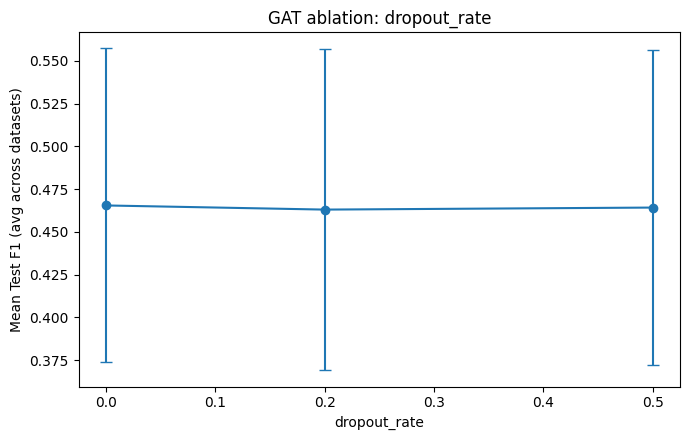

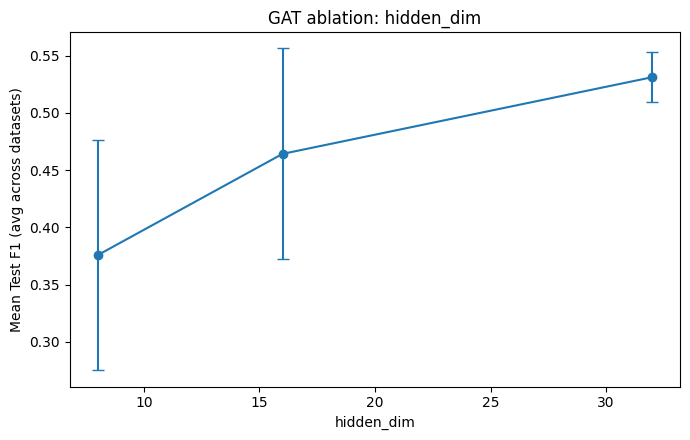

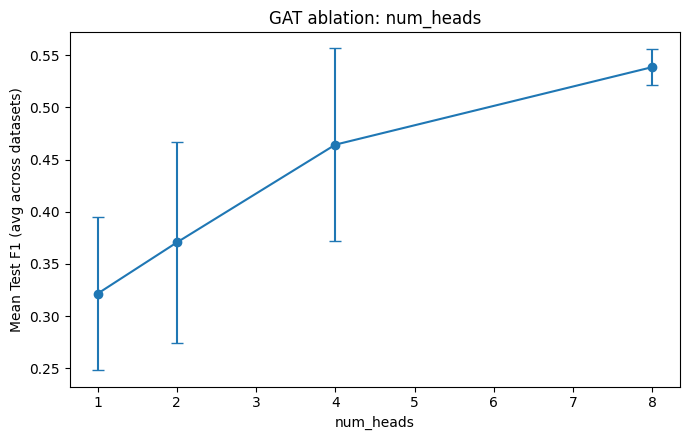

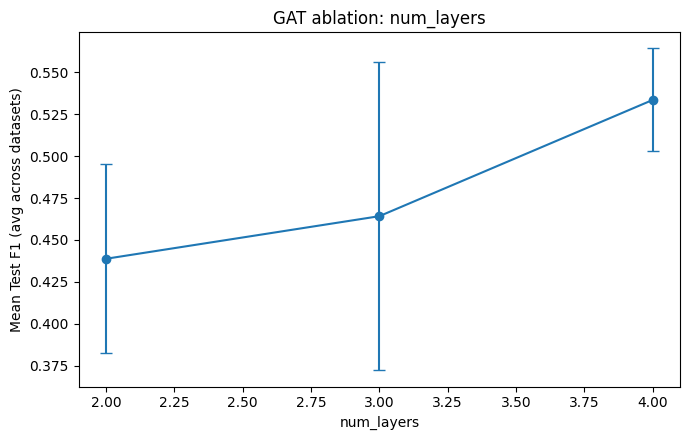

Saved ablation summary to: outputs/metrics/gat_ablation_summary.csv


In [12]:
# ============================================================
# Cell 12: Summarize and plot ablation results
# ============================================================
ablation_summary_df = (
    ablation_results_df
    .groupby(["ablation_type", "ablation_value", "dataset"], as_index=False)
    .agg({
        "test_f1": ["mean", "std"],
        "test_accuracy": ["mean", "std"],
        "test_macro_f1": ["mean", "std"]
    })
)

ablation_summary_df.columns = [
    "ablation_type", "ablation_value", "dataset",
    "test_f1_mean", "test_f1_std",
    "test_accuracy_mean", "test_accuracy_std",
    "test_macro_f1_mean", "test_macro_f1_std"
]

display(ablation_summary_df.head(20))

ablation_summary_path = os.path.join(METRICS_DIR, "gat_ablation_summary.csv")
ablation_summary_df.to_csv(ablation_summary_path, index=False)

# One plot per ablation type: average across datasets
for ablation_type in ablation_summary_df["ablation_type"].unique():
    sub = ablation_summary_df[ablation_summary_df["ablation_type"] == ablation_type].copy()

    collapsed = (
        sub.groupby("ablation_value", as_index=False)
        .agg({
            "test_f1_mean": "mean",
            "test_f1_std": "mean"
        })
        .sort_values("ablation_value")
    )

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        collapsed["ablation_value"].values,
        collapsed["test_f1_mean"].values,
        yerr=collapsed["test_f1_std"].values,
        marker="o",
        capsize=4
    )
    plt.xlabel(ablation_type)
    plt.ylabel("Mean Test F1 (avg across datasets)")
    plt.title(f"GAT ablation: {ablation_type}")
    plt.tight_layout()

    fig_path = os.path.join(FIGURES_DIR, f"gat_ablation_{ablation_type}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

print(f"Saved ablation summary to: {ablation_summary_path}")

## 13 - final summary

In [13]:
# ============================================================
# Cell 13: Final summary table
# ============================================================
# Best default result per dataset by validation F1, then report test metrics
best_default_runs_df = (
    default_results_df
    .sort_values(["dataset", "val_f1", "test_f1"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

final_summary_df = best_default_runs_df[[
    "dataset",
    "seed",
    "hidden_dim",
    "num_layers",
    "num_heads",
    "dropout_rate",
    "learning_rate",
    "weight_decay",
    "best_epoch",
    "val_f1",
    "test_accuracy",
    "test_f1",
    "test_macro_f1",
    "test_roc_auc"
]].copy()

display(final_summary_df)

final_summary_path = os.path.join(METRICS_DIR, "gat_final_summary.csv")
final_summary_df.to_csv(final_summary_path, index=False)

print(f"Saved final summary to: {final_summary_path}")
print("Notebook finished successfully.")

,dataset,seed,hidden_dim,num_layers,num_heads,dropout_rate,learning_rate,weight_decay,best_epoch,val_f1,test_accuracy,test_f1,test_macro_f1,test_roc_auc
0,DE,4,16,3,4,0.5,0.001,0.0001,38,0.769468,0.652632,0.745370,0.599506,0.670991
1,EN,0,16,3,4,0.5,0.001,0.0001,1,0.705882,0.554698,0.707508,0.387528,0.576363
2,ES,2,16,3,4,0.5,0.001,0.0001,104,0.458955,0.678495,0.430476,0.603253,0.664570
3,FR,4,16,3,4,0.5,0.001,0.0001,184,0.520599,0.604882,0.500963,0.586972,0.614516
4,PT,2,16,3,4,0.5,0.001,0.0001,115,0.516129,0.631854,0.475836,0.596067,0.620578
5,RU,0,16,3,4,0.5,0.001,0.0001,161,0.297767,0.646522,0.209184,0.490789,0.504862


Saved final summary to: outputs/metrics/gat_final_summary.csv
Notebook finished successfully.


## 14 - Additional Evaluations

In [ ]:
# ============================================================
# Extra evaluation cell:
# 1) Confusion matrices
# 2) Precision / Recall / Balanced Accuracy / PR-AUC
# 3) Majority-class baseline
# 4) Logistic regression baseline
# 5) Threshold tuning on validation set (for GAT)
#
# This cell re-runs the default GAT once per dataset/seed so we can
# recover probabilities and best parameters, then computes all five
# evaluations and saves the results.
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    average_precision_score,
    accuracy_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression

EXTRA_EVAL_DIR = os.path.join(ROOT_OUTPUT_DIR, "extra_evals")
EXTRA_FIG_DIR = os.path.join(EXTRA_EVAL_DIR, "figures")
EXTRA_CSV_DIR = os.path.join(EXTRA_EVAL_DIR, "metrics")
os.makedirs(EXTRA_EVAL_DIR, exist_ok=True)
os.makedirs(EXTRA_FIG_DIR, exist_ok=True)
os.makedirs(EXTRA_CSV_DIR, exist_ok=True)

THRESHOLD_GRID = np.linspace(0.05, 0.95, 19)

def sigmoid_or_softmax_positive_prob(logits: np.ndarray) -> np.ndarray:
    # For 2-class logits, use softmax probability of class 1
    probs = softmax_numpy(logits)
    return probs[:, 1]

def metrics_from_probs_binary(y_true: np.ndarray, pos_probs: np.ndarray, threshold: float) -> Dict[str, float]:
    y_pred = (pos_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    out = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, average="binary", zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, average="binary", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="binary", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "pr_auc": float(average_precision_score(y_true, pos_probs)) if len(np.unique(y_true)) == 2 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "pred_pos_rate": float(y_pred.mean()),
        "true_pos_rate": float(y_true.mean()),
    }
    return out

def choose_best_threshold_by_val_f1(y_val: np.ndarray, val_pos_probs: np.ndarray, threshold_grid: np.ndarray):
    best_threshold = 0.50
    best_metrics = None
    best_f1 = -1.0

    for thr in threshold_grid:
        m = metrics_from_probs_binary(y_val, val_pos_probs, threshold=thr)
        if m["f1"] > best_f1:
            best_f1 = m["f1"]
            best_threshold = float(thr)
            best_metrics = m

    return best_threshold, best_metrics

def evaluate_majority_baseline(y_train: np.ndarray, y_eval: np.ndarray) -> Dict[str, float]:
    majority_class = int(np.mean(y_train) >= 0.5)
    y_pred = np.full_like(y_eval, fill_value=majority_class)
    # use hard probabilities compatible with metrics requiring probs
    pos_probs = np.full(len(y_eval), float(majority_class), dtype=np.float64)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()

    return {
        "majority_class": majority_class,
        "accuracy": float(accuracy_score(y_eval, y_pred)),
        "f1": float(f1_score(y_eval, y_pred, average="binary", zero_division=0)),
        "precision": float(precision_score(y_eval, y_pred, average="binary", zero_division=0)),
        "recall": float(recall_score(y_eval, y_pred, average="binary", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_eval, y_pred)),
        "pr_auc": float(average_precision_score(y_eval, pos_probs)) if len(np.unique(y_eval)) == 2 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "pred_pos_rate": float(y_pred.mean()),
    }

def evaluate_logreg_baseline(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    seed: int
) -> Dict[str, Dict[str, float]]:
    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=1000,
        random_state=seed
    )
    clf.fit(x_train, y_train)

    val_pos_probs = clf.predict_proba(x_val)[:, 1]
    test_pos_probs = clf.predict_proba(x_test)[:, 1]

    # default threshold 0.5
    test_default = metrics_from_probs_binary(y_test, test_pos_probs, threshold=0.50)

    # tuned threshold from validation
    best_thr, val_best = choose_best_threshold_by_val_f1(y_val, val_pos_probs, THRESHOLD_GRID)
    test_tuned = metrics_from_probs_binary(y_test, test_pos_probs, threshold=best_thr)

    return {
        "default": test_default,
        "tuned": test_tuned,
        "best_threshold": float(best_thr),
        "val_best_f1": float(val_best["f1"]),
    }

def build_default_gat_model_for_x(x_np: np.ndarray, y_np: np.ndarray):
    return GAT(
        input_dim=x_np.shape[1],
        hidden_dim=DEFAULT_CONFIG["hidden_dim"],
        output_dim=len(np.unique(y_np)),
        num_layers=DEFAULT_CONFIG["num_layers"],
        num_heads=DEFAULT_CONFIG["num_heads"],
        dropout_rate=DEFAULT_CONFIG["dropout_rate"]
    )

# ------------------------------------------------------------
# Main evaluation loop
# ------------------------------------------------------------
extra_eval_rows = []

# aggregate confusion matrices for tuned MLP, summed over seeds
agg_confusion_by_dataset = {
    name: {"tn": 0, "fp": 0, "fn": 0, "tp": 0} for name in DATASET_NAMES
}

for dataset_name in DATASET_NAMES:
    x_np = dataset_data[dataset_name]["x_np"]
    y_np = dataset_data[dataset_name]["y_np"]
    edge_index_np = dataset_data[dataset_name]["edge_index_gat_np"]

    print("=" * 90)
    print(f"Running extra evaluations for dataset: {dataset_name}")

    for seed in SEEDS:
        print(f"  Seed {seed} ...")

        splits = all_splits[dataset_name][seed]
        train_idx = splits["train"]
        val_idx = splits["val"]
        test_idx = splits["test"]

        x_train, y_train = x_np[train_idx], y_np[train_idx]
        x_val, y_val = x_np[val_idx], y_np[val_idx]
        x_test, y_test = x_np[test_idx], y_np[test_idx]

        # -----------------------------
        # Re-train default MLP once to recover best params
        # -----------------------------
        gat_result = train_one_run(
            x_np=x_np,
            y_np=y_np,
            edge_index_np=edge_index_np,
            splits=splits,
            seed=seed,
            config=DEFAULT_CONFIG,
            dataset_name=dataset_name,
            run_name="default_gat_extra_eval",
            save_training_curve=False
        )

        best_params = gat_result["best_params"]
        gat_model = build_default_gat_model_for_x(x_np, y_np)
        x_jnp = jnp.asarray(x_np, dtype=JAX_DTYPE)
        edge_index_jnp = jnp.asarray(edge_index_np, dtype=jnp.int32)

        logits_all = np.asarray(gat_model(best_params, x_jnp, edge_index_jnp, rng_key=None, train=False))
        val_pos_probs = sigmoid_or_softmax_positive_prob(logits_all[val_idx])
        test_pos_probs = sigmoid_or_softmax_positive_prob(logits_all[test_idx])

        # 1 + 2: confusion matrix + precision/recall/balanced acc/PR-AUC
        mlp_test_default = metrics_from_probs_binary(y_test, test_pos_probs, threshold=0.50)

        # 5: threshold tuning using validation set
        best_thr_mlp, mlp_val_best = choose_best_threshold_by_val_f1(y_val, val_pos_probs, THRESHOLD_GRID)
        mlp_test_tuned = metrics_from_probs_binary(y_test, test_pos_probs, threshold=best_thr_mlp)

        # 3: majority-class baseline
        majority_test = evaluate_majority_baseline(y_train, y_test)

        # 4: logistic regression baseline
        logreg_out = evaluate_logreg_baseline(
            x_train=x_train,
            y_train=y_train,
            x_val=x_val,
            y_val=y_val,
            x_test=x_test,
            y_test=y_test,
            seed=seed
        )
        logreg_test_default = logreg_out["default"]
        logreg_test_tuned = logreg_out["tuned"]

        # Save per-run rows
        row_common = {
            "dataset": dataset_name,
            "seed": seed,
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "train_pos_frac": float(y_train.mean()),
            "val_pos_frac": float(y_val.mean()),
            "test_pos_frac": float(y_test.mean()),
        }

        extra_eval_rows.append({
            **row_common,
            "model": "gat_default_threshold",
            "threshold_source": "fixed_0.50",
            "selected_threshold": 0.50,
            **mlp_test_default
        })

        extra_eval_rows.append({
            **row_common,
            "model": "gat_tuned_threshold",
            "threshold_source": "best_val_f1",
            "selected_threshold": float(best_thr_mlp),
            "val_best_f1_for_threshold_selection": float(mlp_val_best["f1"]),
            **mlp_test_tuned
        })

        extra_eval_rows.append({
            **row_common,
            "model": "majority_class_baseline",
            "threshold_source": "none",
            "selected_threshold": np.nan,
            **majority_test
        })

        extra_eval_rows.append({
            **row_common,
            "model": "logistic_regression_default_threshold",
            "threshold_source": "fixed_0.50",
            "selected_threshold": 0.50,
            **logreg_test_default
        })

        extra_eval_rows.append({
            **row_common,
            "model": "logistic_regression_tuned_threshold",
            "threshold_source": "best_val_f1",
            "selected_threshold": float(logreg_out["best_threshold"]),
            "val_best_f1_for_threshold_selection": float(logreg_out["val_best_f1"]),
            **logreg_test_tuned
        })

        # aggregate tuned GAT confusion counts across seeds
        agg_confusion_by_dataset[dataset_name]["tn"] += mlp_test_tuned["tn"]
        agg_confusion_by_dataset[dataset_name]["fp"] += mlp_test_tuned["fp"]
        agg_confusion_by_dataset[dataset_name]["fn"] += mlp_test_tuned["fn"]
        agg_confusion_by_dataset[dataset_name]["tp"] += mlp_test_tuned["tp"]

# ------------------------------------------------------------
# Save detailed metrics
# ------------------------------------------------------------
extra_eval_df = pd.DataFrame(extra_eval_rows)
display(extra_eval_df.head(20))

extra_eval_path = os.path.join(EXTRA_CSV_DIR, "extra_eval_detailed_results.csv")
extra_eval_df.to_csv(extra_eval_path, index=False)

# ------------------------------------------------------------
# Save aggregated summary
# ------------------------------------------------------------
extra_eval_summary_df = (
    extra_eval_df
    .groupby(["dataset", "model"], as_index=False)
    .agg({
        "accuracy": ["mean", "std"],
        "f1": ["mean", "std"],
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "balanced_accuracy": ["mean", "std"],
        "pr_auc": ["mean", "std"],
        "selected_threshold": ["mean", "std"],
        "tn": "sum",
        "fp": "sum",
        "fn": "sum",
        "tp": "sum",
    })
)

extra_eval_summary_df.columns = [
    "dataset", "model",
    "accuracy_mean", "accuracy_std",
    "f1_mean", "f1_std",
    "precision_mean", "precision_std",
    "recall_mean", "recall_std",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "pr_auc_mean", "pr_auc_std",
    "selected_threshold_mean", "selected_threshold_std",
    "tn_sum", "fp_sum", "fn_sum", "tp_sum"
]

display(extra_eval_summary_df)

extra_eval_summary_path = os.path.join(EXTRA_CSV_DIR, "extra_eval_summary_results.csv")
extra_eval_summary_df.to_csv(extra_eval_summary_path, index=False)

# ------------------------------------------------------------
# Save compact comparison tables for easy reporting
# ------------------------------------------------------------
comparison_tables = {}
for metric_name in ["f1_mean", "accuracy_mean", "precision_mean", "recall_mean", "balanced_accuracy_mean", "pr_auc_mean"]:
    table = extra_eval_summary_df.pivot(index="dataset", columns="model", values=metric_name)
    comparison_tables[metric_name] = table
    table_path = os.path.join(EXTRA_CSV_DIR, f"comparison_{metric_name}.csv")
    table.to_csv(table_path)
    print(f"Saved: {table_path}")

# ------------------------------------------------------------
# Plot confusion matrices for tuned MLP aggregated across seeds
# ------------------------------------------------------------
for dataset_name in DATASET_NAMES:
    cm = agg_confusion_by_dataset[dataset_name]
    cm_arr = np.array([[cm["tn"], cm["fp"]],
                       [cm["fn"], cm["tp"]]], dtype=np.int64)

    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm_arr)
    plt.title(f"{dataset_name}: GAT tuned-threshold confusion matrix\n(aggregated over seeds)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm_arr[i, j]), ha="center", va="center", fontsize=12)

    plt.tight_layout()
    fig_path = os.path.join(EXTRA_FIG_DIR, f"{dataset_name}_gat_tuned_confusion_matrix.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

# ------------------------------------------------------------
# Plot model comparison for F1 and balanced accuracy
# ------------------------------------------------------------
for metric_base in ["f1", "balanced_accuracy", "precision", "recall", "pr_auc"]:
    metric_mean = f"{metric_base}_mean"
    metric_std = f"{metric_base}_std"

    plot_df = extra_eval_summary_df.copy()
    models_order = [
        "gat_default_threshold",
        "gat_tuned_threshold",
        "majority_class_baseline",
        "logistic_regression_default_threshold",
        "logistic_regression_tuned_threshold"
    ]

    for dataset_name in DATASET_NAMES:
        sub = plot_df[plot_df["dataset"] == dataset_name].copy()
        sub["model"] = pd.Categorical(sub["model"], categories=models_order, ordered=True)
        sub = sub.sort_values("model")

        plt.figure(figsize=(9, 4.5))
        x = np.arange(len(sub))
        plt.bar(x, sub[metric_mean].values, yerr=sub[metric_std].values, capsize=4)
        plt.xticks(x, sub["model"].values, rotation=30, ha="right")
        plt.ylabel(metric_base)
        plt.title(f"{dataset_name}: model comparison ({metric_base})")
        plt.tight_layout()

        fig_path = os.path.join(EXTRA_FIG_DIR, f"{dataset_name}_comparison_{metric_base}.png")
        plt.savefig(fig_path, dpi=200)
        plt.show()

print("\nSaved detailed results to:", extra_eval_path)
print("Saved summary results to:", extra_eval_summary_path)
print("Saved confusion matrices and comparison plots in:", EXTRA_FIG_DIR)

Running extra evaluations for dataset: DE
  Seed 0 ...


In [ ]:
# ============================================================
# Zip everything inside outputs/extra_evals into one zip file
# ============================================================
import os
import zipfile
from datetime import datetime

ROOT_TO_ZIP = os.path.join("outputs", "extra_evals")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = f"extra_evals_outputs_{timestamp}.zip"

if not os.path.exists(ROOT_TO_ZIP):
    raise FileNotFoundError(f"Could not find folder: {ROOT_TO_ZIP}")

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for foldername, _, filenames in os.walk(ROOT_TO_ZIP):
        for filename in filenames:
            full_path = os.path.join(foldername, filename)
            arcname = os.path.relpath(full_path, start=".")
            zf.write(full_path, arcname=arcname)

print(f"Created zip file: {zip_path}")
print(f"Absolute path: {os.path.abspath(zip_path)}")

# Show contents
with zipfile.ZipFile(zip_path, "r") as zf:
    print("\nZip contents:")
    for name in zf.namelist():
        print(" -", name)

Created zip file: extra_evals_outputs_20260429_072124.zip
Absolute path: /content/extra_evals_outputs_20260429_072124.zip

Zip contents:
 - outputs/extra_evals/metrics/comparison_f1_mean.csv
 - outputs/extra_evals/metrics/extra_eval_detailed_results.csv
 - outputs/extra_evals/metrics/comparison_balanced_accuracy_mean.csv
 - outputs/extra_evals/metrics/comparison_precision_mean.csv
 - outputs/extra_evals/metrics/comparison_pr_auc_mean.csv
 - outputs/extra_evals/metrics/comparison_recall_mean.csv
 - outputs/extra_evals/metrics/comparison_accuracy_mean.csv
 - outputs/extra_evals/metrics/extra_eval_summary_results.csv
 - outputs/extra_evals/figures/FR_comparison_balanced_accuracy.png
 - outputs/extra_evals/figures/PT_comparison_f1.png
 - outputs/extra_evals/figures/RU_comparison_recall.png
 - outputs/extra_evals/figures/EN_comparison_pr_auc.png
 - outputs/extra_evals/figures/ES_comparison_balanced_accuracy.png
 - outputs/extra_evals/figures/FR_comparison_f1.png
 - outputs/extra_evals/figur

In [ ]:
# ============================================================
# Final extra cell: bundle all notebook outputs into one zip
# ============================================================
import os
import zipfile
from datetime import datetime

ROOT_TO_ZIP = "outputs"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = f"gat_notebook_outputs_{timestamp}.zip"

if not os.path.exists(ROOT_TO_ZIP):
    raise FileNotFoundError(f"Could not find output directory: {ROOT_TO_ZIP}")

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for foldername, _, filenames in os.walk(ROOT_TO_ZIP):
        for filename in filenames:
            full_path = os.path.join(foldername, filename)
            arcname = os.path.relpath(full_path, start=".")
            zf.write(full_path, arcname=arcname)

print(f"Created zip file: {zip_path}")
print(f"Absolute path: {os.path.abspath(zip_path)}")

# Optional: show contents
with zipfile.ZipFile(zip_path, "r") as zf:
    print("\nZip contents:")
    for name in zf.namelist():
        print(" -", name)